# Регрессии и логистическая регрессия

Две базовые задачи ML -- классификация и регрессия

Классификация: $\mathbb{X} \rightarrow \{0, 1, \dots, K\}$

Регрессия: $\mathbb{X}\rightarrow \mathbb{R} $

Эти два занятия мы изучаем функции вида:

$y = w_1x_1+w_2x_2 +\dots+ w_nx_n + w_0$, 

где $y$ — целевая переменная (таргет);

$x = (x_1,x_2,\dots,x_n)$ — вектор, соответствующий объекту выборки (вектор признаков);

$w_0, w_1, w_2,\dots w_n$ — параметры модели.

В векторном виде: $y=\langle x,w \rangle + w_0$

В смысле задачи регрессии все понятно -- мы получили линейную функцию, она действует в действительные числа и все хорошо. 

Что делать с классификацией?
Для начала задача для бинарной классификации (у таргета есть только два класса)

Ваши варианты???

![image.png](https://yastatic.net/s3/education-portal/media/1_1_02255c591c_b62e3f69e1_ad43f2c5e3.webp)

В случае более высоких размерностей вместо прямой будет гиперплоскость с аналогичным смыслом.

__Вопрос : что вес говорит о признаке?__

<details>
    <summary>Ответ</summary>
Скажем, если вес 
$w_i$ положителен, то с ростом i-го признака таргет в случае регрессии будет увеличиваться, а в случае классификации наш выбор будет сдвигаться в пользу одного из классов.

Значение весов тоже имеет прозрачную интерпретацию: чем вес 
$w_i$ больше, тем «важнее» i-й признак для итогового предсказания.

То есть если вы построили линейную модель, вы неплохо можете объяснить те или иные её результаты. Это качество моделей называют интерпретируемостью. По этой причине! , поведение искусственных нейронных сетей или градиентного бустинга интерпретировать довольно сложно.</details>

В то же время слепо доверять весам линейных моделей тоже не стоит по целому ряду причин.

__Вопрос : почему не стоит? Ваши варианты__

<details>
    <summary>
        Ответ
    </summary>
    <b>Во-первых</b>, линейные модели — всё-таки довольно узкий класс функций. Они неплохо работают для небольших датасетов и простых задач.

Однако если вы решаете линейной моделью более сложную задачу, то вам, скорее всего, придётся выдумывать дополнительные признаки, которые будут сложными функциями от исходных. Поиск дополнительных признаков называется feature engineering. Вот только поиском таких искусственных фич можно сильно увлечься, так что осмысленность интерпретации будет сильно зависеть от здравого смысла эксперта, строившего модель.

<b>Во-вторых</b>, если между признаками есть приближённая линейная зависимость, коэффициенты в линейной модели могут совершенно потерять физический смысл. Об этой проблеме и о том, как с ней бороться, мы поговорим дальше, когда будем обсуждать регуляризацию.

<b>В-третьих</b>, особенно осторожно стоит верить в утверждения вида «Этот коэффициент маленький, значит, этот признак не важен».

* Всё зависит от масштаба признака: вдруг коэффициент мал, чтобы скомпенсировать его.
* Зависимость действительно может быть слабой, но кто знает, в какой ситуации она окажется важна.
Такие решения принимаются на основе данных, например путём проверки статистического критерия — об этом позже.

<b>В-четвёртых</b>, конкретные значения весов могут меняться в зависимости от обучающей выборки, хотя с ростом её размера они будут потихоньку сходиться к весам «наилучшей» линейной модели, которую можно было бы построить по всем-всем-всем данным на свете -- в статистике это называется ЗБЧ
</details>

### Градиентные методы
Как уже говорили ранее, зачастую обращать матрицу себе дороже. Попробуем метод градиентного спуска.
Каждый шаг алгоритма веса изменяются следующим образом:
$$W_{k+1} = W_{k} - \alpha \nabla_{W_{k}} L(f_{W_{k}},X, y)$$

Например, для $L(f_W,X, y) = \frac{1}{N}||f_W(X) -y\;||^2 = \frac{1}{N}||XW -y\;||^2$

$$\nabla_W L = \frac{2}{N}X^T(XW -y\;)$$


Алгоритм
```pascal
w = random_normal()             # можно пробовать и другие виды инициализации
repeat S times:                 # другой вариант: while abs(err) > tolerance
   f = X.dot(w)                 # посчитать предсказание
   err = f - y                  # посчитать ошибку
   grad = 2 * X.T.dot(err) / N  # посчитать градиент
   w -= alpha * grad            # обновить веса

```

Минусы — считать градиент оказывается тоже дорого 

Вычислительная сложность градиентного спуска — $O(NDS)$, где, как и выше, N — длина выборки, D — число признаков у одного объекта, S — число итераций. Сравните с оценкой 
$O(D^2N+D^3)$ для «наивного» вычисления аналитического решения.

Сложность по памяти — $O(ND)$ на хранение выборки. В памяти мы держим и выборку, и градиент, но в большинстве реалистичных сценариев доминирует выборка.

### Регуляризация

Всегда ли решение задачи регрессии единственно? Вообще говоря, нет. Так, если в выборке два признака будут линейно зависимы (и, следовательно, ранг матрицы будет меньше $D$), то гарантированно найдётся такой вектор весов $\nu$, что $\langle \nu, x_i \rangle = 0 \quad \forall x_i$

Значит, что для любого решения $w$ также будет решением $w + \alpha \nu$

Важно ещё отметить, что в случае, когда несколько признаков линейно зависимы, веса $w_i$ при них теряют физический смысл. Может даже оказаться, что вес признака, с ростом которого таргет, казалось бы, должен увеличиваться, станет отрицательным. Это делает модель не только неточной, но и принципиально не интерпретируемой. Вообще, неадекватность знаков или величины весов — хорошее указание на мультиколлинеарность.

Для того, чтобы справиться с этой проблемой, задачу обычно регуляризуют, то есть добавляют к ней дополнительное ограничение на вектор весов. Это ограничение можно, как и исходный лосс, задавать по-разному, но, как правило, ничего сложнее, чем 
$L_1$ и $L_2$-нормы, не требуется.

Новая задача оптимизации!!!

$\displaystyle
\min_w L(f,X,y) = \min_w (||XW -y\;||^2_2 + \lambda||W||^k_k)
\:$, где $k\in {1,2}$


Добавка $\lambda||W||^k_k$ называется регуляризационным членом или регуляризатором, а число $\lambda$ — коэффициентом регуляризации

Помним, что $w_0$ (свободный коэффициент) — не идет в регуляризацию (потому что он впомлне может быть большим и не зависит линейно от остальных признаков)



### Функции потерь у линейной регресии

1. $\displaystyle MAE(y,\hat{y}) = \frac{1}{N}\sum\limits_{i=1}^{N} |y_i-\hat{y_i}|$
   
   Можно заметить, что в MAE, по сравнению с MSE, существенно меньший вклад в ошибку будут вносить примеры, сильно удалённые от ответов модели. Так как в MAE мы считаем модуль расстояния, а не квадрат, вклад больших ошибок в MSE получается существенно больше. Поэтому такая функция потерь уместна в случаях, когда вы пытаетесь обучить регрессию на данных с большим количеством выбросов в таргете.

   Иначе на эту разницу можно посмотреть так: MSE приближает матожидание условного распределения $p(y∣x)$, а MAE — медиану

2. $\displaystyle MAPE(y,\hat{y}) = \frac{1}{N}\sum\limits_{i=1}^{N} \left|\frac{y_i-\hat{y_i}}{y_i}\right|$

   Часто используется в задачах прогнозирования (например, погоды, загруженности дорог, кассовых сборов фильмов, цен), когда ответы могут быть различными по порядку величины и при этом мы бы хотели верно угадать порядок, то есть мы не хотим штрафовать модель за предсказание  2000 вместо 1000 в разы сильней, чем за предсказание 2 вместо 1


### Линейная классификация
Теперь давайте поговорим про задачу классификации. Для начала будем говорить про бинарную классификацию на два класса (Для большего количества классов аналогично)

Пусть теперь наши таргеты $y$ кодируют принадлежность к положительному или отрицательному классу, то есть принадлежность множеству $\{-1,1\}$ или $\{0,1\}$, а $x$ — по-прежнему векторы из $\mathbb{R}^D$.

Мы хотим обучить линейную модель так, чтобы плоскость, которую она задаёт, как можно лучше отделяла объекты одного класса от объектов другого. 
![classification.png](https://yastatic.net/s3/education-portal/media/image_5_b606f0886b.webp)

В идеальной ситуации найдётся плоскость, которая разделит классы: положительный окажется с одной стороны от неё, а отрицательный — с другой. Выборка, для которой это возможно, называется линейно разделимой.В реальной жизни такое встречается крайне редко :(.

Как обучить линейную модель классификации я расскажу позже, но уже ясно, что итоговое предсказание можно будет вычислить по формуле:
$$ y_i = sign (\langle w,x_i\rangle)$$

__Вопрос: почему мы не можем организовать тут обычную задачу регресии (просто предсказывать числа -1 и 1)?__
<details>
    <summary>Ответ</summary>
    Мы можем попробовать предсказывать числа -1 и 1, минимизируя для этого, например, MSE с последующим взятием знака, но ничего хорошего не получится.
    
* Во-первых, регрессия почти не штрафует за ошибки на объектах, которые лежат близко к разделяющей плоскости, но не с той стороны.
* Во вторых, ошибкой будет считаться предсказание, например, 5 вместо 1, хотя нам-то на самом деле не важно, какой у числа модуль, лишь бы знак был правильным.

</details>

Сформулируем задачу тогда уж
Давайте скажем, что мы предсказываем числа -- например вероятность класса?

Возьмем классы 0 и 1.

__Вопрос: в линейной регрессии мы предсказываем числа в диапазоне $(-\infty, \infty)$, а вероятность в диапазоне [0,1], что делать?__


<details>
    <summary>Ответ</summary>
    
Научить линейную модель правильно предсказывать какой-то объект, связанный с вероятностью, но с диапазоном значений $(-\infty, \infty)$, и преобразовать ответы модели в вероятность. Одним из таких преобразований является логиты -- логарифм отношения вероятности что нужный класс выберут к вероятности, что не выберут $\log\left(\frac{p}{1-p}\right)$.

Если ответом нашей модели будет логит, то можно просто посчитать, чеу будет равна вероятность
$$\langle w, x_i\rangle = \log\left(\frac{p}{1-p}\right)$$
$$\displaystyle e^{\langle w, x_i\rangle} = \frac{p}{1-p}$$
$$ p = \frac{1}{1+ e^{-\langle w, x_i\rangle}}$$

Функция которая получилась называется сигмойдой.
</details>

### Придумываем лосс (функцию потерь)

Воспользуемся принципом правдоподобия (узнаете на курсе статистики подробнее) для распределения Бернулли -- это когда бросают монетку.

Функция вероятности очень простая -- p если выпало 1, 1 - p -- если выпало 0.

Функция правдоподобия (произведение функций вероятности в точках, для которых мы знаем исход) для распределения Бернулли выглядит следующим образом

$\displaystyle p(y|X,w) = \prod\limits_{i=1}^{N}p(y_i|x_i,w)=\prod\limits_{i=1}^{N}p_i^{y_i}(1-p_i)^{1-y_i}$

Оптимизировать произведение неудобно -- возьмем от него логарифм

$\mathcal{l}(y|X,w) = \sum\limits_{i=1}^{N}\log{p_i^{y_i}} + \log{(1-p_i)^{1-y_i}} = \sum\limits_{i=1}^{N} y_i\log{p_i} + (1-y_i)\log{(1-p_i)} $

Данную вещь мы хотели максимизировать (максимизировать правдоподобие), соответственно лосс будет со знаком минуса

$L(y|X,w) = \sum\limits_{i=1}^{N}\log{p_i^{y_i}} + \log{(1-p_i)^{1-y_i}} = \sum\limits_{i=1}^{N} y_i\log{p_i} + (1-y_i)\log{(1-p_i)} $


# Логистическая регрессия в `sklearn` и метрики качества классификации

In [3]:
import numpy as np

from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, fbeta_score, roc_curve, precision_recall_curve, auc, 
    average_precision_score
)

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='darkgrid', font_scale=1.3, palette='Set2')

## 1. Логистическая регрессия в `sklearn`

### [`sklearn.linear_model.LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)


* Наиболее важные параметры:
    * `penalty` &mdash; задает норму регуляризатора, возможные варианты: `{‘l1’, ‘l2’, ‘elasticnet’, ‘none’}`, по-умолчанию `’l2’`;
    * `C` &mdash; константа, обратная к константе перед регуляризацией, т.е. *меньшие значения указывают на более сильную регуляризацию*, по-умолчанию $1.0$;
    * `fit_intercept` &mdash; указывает, следует ли добавить константу к исходным признакам, по-умолчанию `True`;
    * `multi_class` &mdash; стратегия при мультиклассовой классификации, возможные варианты: `{‘auto’, ‘ovr’, ‘multinomial’}` по-умолчанию `’auto’`;
    * `solver` &mdash; метод оптимизации, возможные варианты: `{‘newton-cg’, ‘lbfgs’, ‘liblinear’, ‘sag’, ‘saga’}`, по-умолчанию `'lbfgs'`.
* Наиболее важные аттрибуты:
    * `coef_` &mdash; оценки коэффициентов логистической регрессии;
    * `intercept_` &mdash; оценка коэффициента перед единичным признаком;
* Методы:
    * `fit()` &mdash; обучение классификатора;
    * `predict()` &mdash; предсказание метки класса;
    * `predict_proba()` &mdash; предсказание вероятностей классов;
    * `predict_log_proba()` &mdash; предсказание логарифмов вероятностей классов;
    * `decision_function()` &mdash; значения перед применением сигмоиды, характеризуют степень уверенности модели в предсказании.

### 1.1 Данные

В качестве примера рассмотрим данные для бинарной классификации с двумя признаками. Классы несбалансированны и линейно не разделимы.

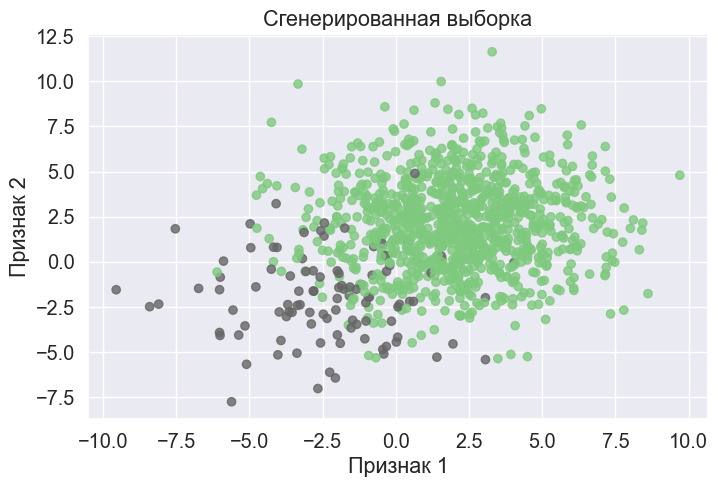

In [4]:
X, y = make_blobs(
    n_samples=(1000, 100),
    centers=[[2, 2], [-2, -2]],
    cluster_std=2.5,
    random_state=42
)

plt.figure(figsize=(8, 5))
plt.title('Сгенерированная выборка')
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.8, cmap='Accent')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.show()

Разделим данные на обучающую и тестовую выборку:

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15)

Выведем размерности выборок:

In [6]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((935, 2), (165, 2), (935,), (165,))

### 1.2 Модель

Определим модель логистической регресии и обучим ее:

In [7]:
clf = LogisticRegression(random_state=42)
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Выведем коэффициенты модели:

In [8]:
clf.coef_

array([[-0.82564675, -0.75943452]])

Выведем коэффициент перед свободным параметром:

In [9]:
clf.intercept_

array([-2.38849754])

### 1.3 Результат

График предсказаний вероятности принадлежности классу:

In [10]:
x0_grid, x1_grid = np.meshgrid(np.linspace(-10, 10, 2001), np.linspace(-10, 10, 2001))
ravel_grid = np.array([x0_grid, x1_grid]).reshape((2, 2001*2001)).T

prob_grid = clf.predict_proba(ravel_grid)
prob_grid = prob_grid[:, 0].reshape((2001, 2001))

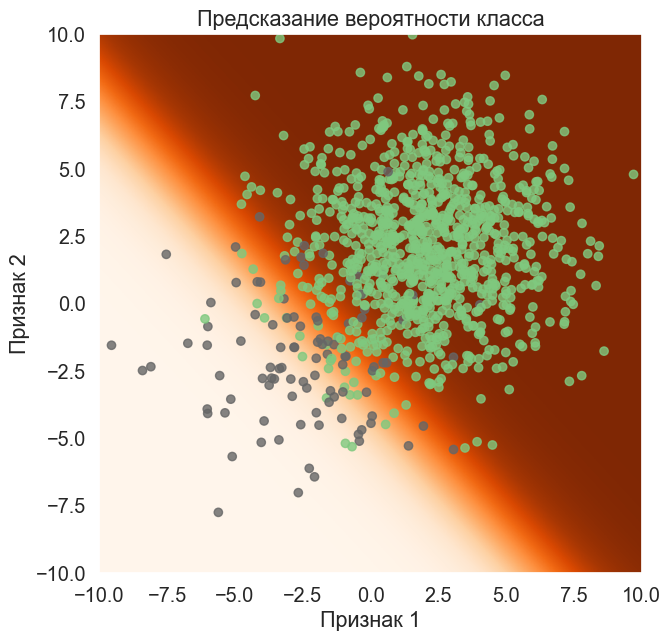

In [11]:
plt.figure(figsize=(7, 7))
plt.pcolormesh(x0_grid, x1_grid, prob_grid, cmap='Oranges', shading='auto')
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.8, cmap='Accent')
plt.xlim((-10, 10))
plt.ylim((-10, 10))
plt.xlabel('Признак 1'), plt.ylabel('Признак 2')
plt.title('Предсказание вероятности класса');

## 2. Метрики качества классификации

Для бинарной классификации существует множество различных метрик качества. В этом ноутбуке рассмотрим самые основные.

### 2.1 Accuracy (доля правильных ответов)

[Accuracy в `sklearn`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)

Данная метрика является самой тривиальной метрикой для задачи классификации и представляет собой долю правильных ответов:

$$accuracy(y, \widehat{y}) = \frac{1}{n}\sum\limits_{i=1}^{n} {I\{y_i = \widehat{y}_i\}},$$   
  
где $y$ &mdash; вектор истинных классов, $\widehat{y}$ &mdash; вектор предсказанных классов, $n$ &mdash; количество объектов.

**Достоинство**: в основе метрики $accuracy$ лежит простая интуиция.

**Недостаток**: данная метрика плоха в случае дисбаланса классов, когда представителей одного из класса существенно больше, чем другого.

> Рассмотрим пример выборки, в которой $950$ положительных и $50$ отрицательных объектов. Пусть наш классификатор всем объектам выдает класс $1$. Тогда его accuracy будет равен $0.95$, что является очень неплохим результатом. Однако сама модель при этом не имеет особого смысла: она просто возвращает константу при любом входе.

Это означает, что доля правильных ответов сама по себе не несет никакой информации о качестве работы модели, и вместе с ней следует анализировать соотношение классов в выборке.

**Пример вычисления**

Вычислим $accuracy$ для нашей задачи:

In [12]:
accuracy = accuracy_score(y_test, clf.predict(X_test))
print(f'Accuracy: {accuracy:.3f}')

Accuracy: 0.939


В данной ситуации эта метрика не очень информативна, так как классификатор, предсказывающий всегда 1 класс, имел бы accuracy $\approx 90\%$ 

### 2.2 Confusion matrix (матрица ошибок)

[Confusion matrix в `sklearn`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)

Рассмотрим  матрицу ошибок (confusion matrix) – матрицу размера $2 \times 2$, в которой $ij$-я позиция которой равна числу объектов $i$-го класса, которым модель присвоила метку $j$-го класса. Данное понятие нужно осознать и запомнить, так как на основе данной матрицы будут введены более сложные метрики.

<img src="https://1.bp.blogspot.com/-PvE3PVpfZA8/X0TtSgm8MwI/AAAAAAAAXkU/xYqLcaQHzfQ_810vUdzv6U7oPhhwcDMSACLcBGAsYHQ/s1051/1_fxiTNIgOyvAombPJx5KGeA.png" alt="drawing" width="700"/>

**TN** &mdash; True Negative, количество верно (True) предсказанных объектов среди тех, которым модель присвоила негативный (Negative) класс.  
**FP** &mdash; False Positive, количество неверно (False) предсказанных объектов среди тех, которым модель присвоила позитивный (Positive) класс.  
**FN** &mdash; False Negative, количество неверно (False) предсказанных объектов среди тех, которым модель присвоила негативный (Negative) класс.  
**TP** &mdash; True Positive, количество верно (True) предсказанных объектов среди тех, которым модель присвоила позитивный (Positive) класс.  




Отметим, что в данной терминологии $accuracy$ можно представить через следующую формулу:  
<br>
$$accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

> **Пример**
> 
> Пусть мы хотим оценить работу спам-фильтра почты. У нас есть 
> * $100$ не-спам писем, $90$ из которых наш классификатор определил верно 
> * $10$ спам-писем, $5$ из которых классификатор также определил верно.
> 
> Будем считать класс не-спам писем отрицательным, а класс спам писем &mdash; положительным. Обозначим количество объектов отрицательного класса $N_0$, а положительного $N_1$, тогда:
> 
> $$N_0 = TN + FP = 100,$$
> $$N_1 = TP + FN = 10.$$
> 
> Итого:
> * Из $100$ не-спам писем $90$ были определены верно $\Rightarrow TN = 90, \; FP = 10$;
> * Из $10$ спам писем 5 были определены верно $\Rightarrow TP = 5, \; FN = 5$.

Данная матрица сама по себе является не метрикой, а инструментом, с помощью которого можно ввести более продвинутые метрики. Тем не менее ее полезно визуализировать, так как она является достаточно информативной. 

**Пример вычисления**

Вычислим матрицу ошибок для нашей задачи:

In [13]:
matrix = confusion_matrix(y_test, clf.predict(X_test))
(TN, FP), (FN, TP) = matrix
print(f'TN = {TN}')
print(f'FP = {FP}')
print(f'FN = {FN}')
print(f'TP = {TP}')

TN = 148
FP = 6
FN = 4
TP = 7


### 2.3 Precision (точность)

[Precision в `sklearn`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html)

Точность (Precision, Positive Predictive Value) показывает какой процент объектов, которые метод посчитал положительными, действительно являются положительными:

$$precision(y, \widehat{y}) = \frac{TP}{TP + FP},$$

где $y$ &mdash; вектор истинных классов, $\widehat{y}$ &mdash; вектор предсказанных классов.


> **Пример:**
> 
> Рассмотрим задачу предсказания реакции клиента банка на звонок с предложением кредита.
> * Класс $y = 1$ означает, что клиент возьмет кредит после рекламного звонка,
> * класс $y = -1$, что не возьмет.
>   
> Планируется обзванивать только тех клиентов, которых классификатор отнесет к классу $1$.
> Если классификатор имеет высокую точность, то практически все клиенты, которым будет сделано предложение, откликнутся на него.

**Достоинство**: позволяет следить за тем, насколько можно доверять модели, если она предсказывает позитивный класс.

**Недостаток**: не позволяет следить за тем, как много положительных объектов способен распознать классификатор.

Например, мы построили модель, которая присваивает позитивный класс очень малому количеству объектов. $Precision$ у такой модели может быть хорошим, но при этом модель присваивает негативный класс очень большому количеству позитивных объектов. 

**Пример вычисления**

Вычислим $precision$ для нашей задачи:

In [14]:
precision = precision_score(y_test, clf.predict(X_test))
print(f'Precision = {precision:.3f}')

Precision = 0.538


### 2.4 Recall (полнота)

[Recall в `sklearn`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)

Полнота (Recall, True Positive Rate) показывает какую долю объектов положительного класса модель классифицировала правильно:

$$recall(y, \widehat{y}) = \frac{TP}{TP + FN},$$

где $y$ &mdash; вектор истинных классов, $\widehat{y}$ &mdash; вектор предсказанных классов.


> **Пример:**
> 
> Рассмотрим тот же пример предсказания реакции клиента банка на звонок с предложением кредита.
> 
> Если классификатор имеет высокую полноту, то предложение будет сделано практически всем клиентам, которые готовы откликнуться на него.

**Достоинство**: позволяет следить за тем, как много положительных объектов способен распознать классификатор. 

**Недостаток**: не позволяет следить за тем, насколько можно доверять модели, если она предсказывает позитивный класс.

**Пример вычисления**

Вычислим $recall$ для нашей задачи:

In [15]:
recall = recall_score(y_test, clf.predict(X_test))
print(f'Recall = {recall:.3f}')

Recall = 0.636


*Замечания.*

1. Пограничные случаи
   * Легко построить модель с $recall = 1$. Она все объекты относит к классу $1$, но при этом $precision$ может быть очень низким. 
   * Нетрудно построить модель с $precision$ близким к $1$. Она относит к классу $1$ только те объекты, в которых точно уверена, при этом $recall$ может быть низким.
2. Отметим, что точность и полнота не зависят от соотношения размеров классов. Даже если объектов положительного класса на порядки меньше, чем объектов отрицательного класса, данные показатели будут корректно отражать качество работы модели.

## 4. Логистическая регрессия на практике.

Рассмотрим простой датасет на $30$ признаков `load_breast_cancer` из библиотеки `sklearn`. Это относительно простой для бинарной классификации датасет по диагностике рака молочной железы.

Ради интереса можно прочитать описание признаков.

In [18]:
dataset = load_breast_cancer()
dataset['DESCR'].split('\n')[11:31]

[':Attribute Information:',
 '    - radius (mean of distances from center to points on the perimeter)',
 '    - texture (standard deviation of gray-scale values)',
 '    - perimeter',
 '    - area',
 '    - smoothness (local variation in radius lengths)',
 '    - compactness (perimeter^2 / area - 1.0)',
 '    - concavity (severity of concave portions of the contour)',
 '    - concave points (number of concave portions of the contour)',
 '    - symmetry',
 '    - fractal dimension ("coastline approximation" - 1)',
 '',
 '    The mean, standard error, and "worst" or largest (mean of the three',
 '    worst/largest values) of these features were computed for each image,',
 '    resulting in 30 features.  For instance, field 0 is Mean Radius, field',
 '    10 is Radius SE, field 20 is Worst Radius.',
 '',
 '    - class:',
 '            - WDBC-Malignant',
 '            - WDBC-Benign']

Разделим нашу выборку на обучающую и тестовую:

In [19]:
X, Y = dataset['data'], dataset['target']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=17
)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((455, 30), (114, 30), (455,), (114,))

При использовании регуляризации данные необходимо нормализовать. Воспользуемся для этого классом `StandardScaler` из библиотеки `sklearn`. 

In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Обучим модель.

In [21]:
clf = LogisticRegression()
clf.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Посмотрим на основные метрики. 

In [22]:
accuracy = accuracy_score(Y_test, clf.predict(X_test))
print(f'Accuracy: {accuracy:.3f}')

precision = precision_score(Y_test, clf.predict(X_test))
print(f'Precision = {precision:.3f}')

recall = recall_score(Y_test, clf.predict(X_test))
print(f'Recall = {recall:.3f}')

f1 = f1_score(Y_test, clf.predict(X_test))
print(f'F1 = {f1:.3f}')

Accuracy: 0.974
Precision = 0.962
Recall = 1.000
F1 = 0.981


Посмотрим, как на качество влияет коэффициент регуляризации.

In [23]:
# массивы для результатов
recall_values = []
accuracy_values = []
k = 10  # будем усреднять результаты по нескольким запускам
coefs = np.logspace(-5, 3, 9)  # сетка параметров регуляризации

for coef in coefs:
    recall_values_tmp = []
    accuracy_values_tmp = []

    # k раз обучаем модель и считаем среднее целевых метрик.
    for i in range(k):
        clf = LogisticRegression(C=1/coef, solver='sag', max_iter=int(1e4))
        clf.fit(X_train, Y_train)

        accuracy_values_tmp.append(
            accuracy_score(Y_test, clf.predict(X_test))
        )
        recall_values_tmp.append(
            recall_score(Y_test, clf.predict(X_test))
        )

    recall_values.append(np.mean(recall_values_tmp))
    accuracy_values.append(np.mean(accuracy_values_tmp))

Отрисуем графики.

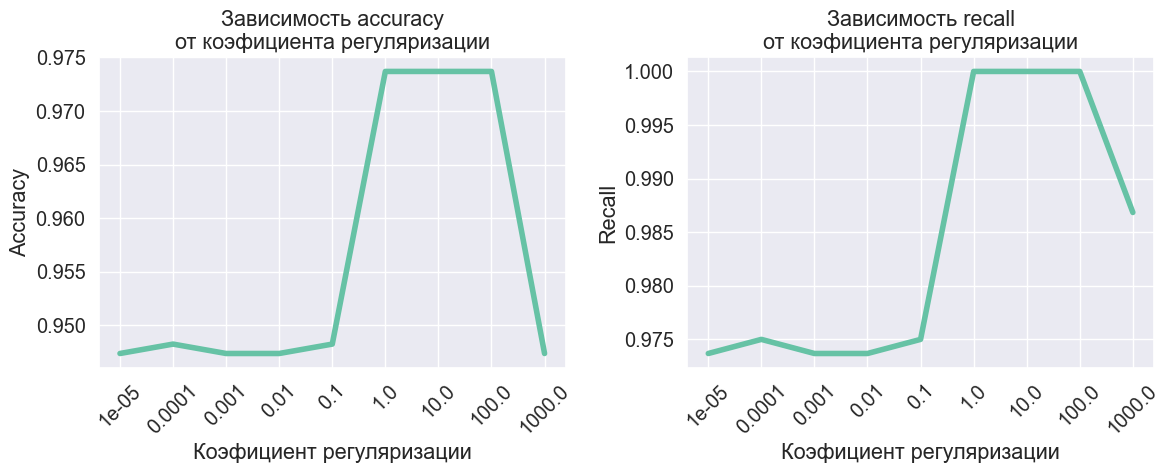

In [24]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title('Зависимость accuracy\nот коэфициента регуляризации')
plt.plot(accuracy_values, lw=4)
plt.xlabel('Коэфициент регуляризации')
plt.ylabel('Accuracy')
plt.xticks(ticks=np.arange(len(coefs)), labels=coefs, rotation=45)

plt.subplot(1, 2, 2)
plt.title('Зависимость recall\nот коэфициента регуляризации')
plt.plot(recall_values, lw=4)
plt.xlabel('Коэфициент регуляризации')
plt.ylabel('Recall')
plt.xticks(ticks=np.arange(len(coefs)), labels=coefs, rotation=45)

plt.tight_layout()
plt.show()

Видим, что наилучшее значение целевых метрик достигается при наличии некоторой регуляризации. Обратим внимание, что значение параметра регуляризации следует подбирать на валидации, а не на тесте.

### Домашнее задание: Логистическая регрессия — отделяем сигнал от фона
Срок сдачи: 1 марта 23:59

Данные взяты из Sloan Digital Sky Survey (SDSS).
Наблюдения описывают объекты на небе: звёзды (STAR), галактики (GALAXY) и квазары (QSO).
Задача — построить мультиклассовый классификатор, который по фотометрическим и спектральным признакам отличает эти три типа объектов.

Целевые классы (колонка class):

GALAXY
STAR
QSO

Основные признаки:
* u, g, r, i, z — магнитуды в пяти фотометрических полосах SDSS
* redshift — красное смещение (очень важный признак для квазаров)
* run, rerun, cam_col, field — технические метки наблюдения 
* obj_ID, spec_obj_ID — идентификаторы 
* plate, MJD, fiber_ID — тоже технические 

Что нужно сделать:

* Загрузить [датасет](https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17)
* Провести разведочный анализ:
df.info(), df.describe()
распределения redshift по классам (sns.histplot)
диаграмма рассеяния u-g vs g-r с hue='class' (классический цветовой график)
pairplot или corr heatmap по выбранным признакам
сколько объектов каждого класса?

* Предобработка:
    * удалить ненужные колонки (в отчете объяснить почему)
    * создать цвета: u-g, g-r, r-i, i-z
    * обработать пропуски (если есть)
    * закодировать целевую переменную class в числа (0,1,2) с помощью LabelEncoder или map
    * разбить на train / test / val (например 70/15/15 или 80/20)

Обучить логистическую регрессию тремя способами (все — мультикласс):

a) Без регуляризации

b) С регуляризацией l1
 
c) С регуляризацией l2 


Выводы о модели (минимум 4–6 предложений):
* какой класс классифицируется лучше/хуже всего?
* где модель ошибается чаще всего?
* помогает ли L2-регуляризация?

Сделать выводы о признаках (3–6 предложений):
* какой признак оказался самым важным?
* почему были выбраны
* насколько важен признак redshift?
* как влияет добавление цветов (u-g и т.д.)?


In [28]:
!pip install kaggle




   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   -------------------- ------------------- 2/4 [kagglesdk]
   ------------------------------ --------- 3/4 [kaggle]
   ---------------------------------------- 4/4 [kaggle]



In [31]:
!kaggle datasets download -d fedesoriano/stellar-classification-dataset-sdss17  --unzip

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17
License(s): copyright-authors




  0%|          | 0.00/6.89M [00:00<?, ?B/s]
 15%|#4        | 1.00M/6.89M [00:00<00:04, 1.46MB/s]
 29%|##9       | 2.00M/6.89M [00:00<00:02, 2.30MB/s]
 44%|####3     | 3.00M/6.89M [00:01<00:01, 2.97MB/s]
 58%|#####8    | 4.00M/6.89M [00:01<00:00, 3.47MB/s]
 73%|#######2  | 5.00M/6.89M [00:01<00:00, 4.14MB/s]
 87%|########7 | 6.00M/6.89M [00:01<00:00, 4.52MB/s]
100%|##########| 6.89M/6.89M [00:01<00:00, 4.81MB/s]
100%|##########| 6.89M/6.89M [00:01<00:00, 3.67MB/s]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


### Анализ датасета

In [ ]:
df = pd.read_csv('star_classification.csv')

print("\nLДатасет star_classification")
print(df.head())

print("\nИнформация о датасете:")
print(df.info())

print("\nОсновная статистика:")
print(df.describe())

print("\nКоличество объектов по классам:")
print(df['class'].value_counts())

plt.figure()
sns.countplot(data=df, x='class')
plt.title('Распределение классов (GALAXY, STAR, QSO)')
plt.show()

plt.figure()
sns.histplot(data=df, x='redshift', hue='class', element='step', alpha=0.5)
plt.title('Распределение redshift по классам')
plt.show()

# Цвета для признаков
df['u_g'] = df['u'] - df['g']
df['g_r'] = df['g'] - df['r']

plt.figure()
sns.scatterplot(data=df, x='u_g', y='g_r', hue='class', alpha=0.5, s=50)
plt.title('Диаграмма рассеяния: u-g vs g-r')
plt.show()

numeric_cols = ['u', 'g', 'r', 'i', 'z', 'redshift', 'u_g', 'g_r']
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица признаков')
plt.show()


### Обработка данных

In [ ]:
# Удаляю колонки, где нет физических данных, это может внести шум
cols_to_drop = ['obj_ID', 'alpha', 'delta', 'run_ID', 'rerun_ID', 
                'cam_col', 'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']

data = df.drop(columns=cols_to_drop)

# Доп цвета для признаков
data['r_i'] = data['r'] - data['i']
data['i_z'] = data['i'] - data['z']

print("\nПропуски в данных после очистки:")
print(data.isnull().sum())

# Кодирование целевой переменной
le = LabelEncoder()
data['class_encoded'] = le.fit_transform(data['class'])
print("\nКодировка классов:", dict(zip(le.classes_, le.transform(le.classes_))))

# Разделение на признаки и таргет
X = data.drop(columns=['class', 'class_encoded'])
y = data['class_encoded']

# Разбиение на train / val / test (70% / 15% / 15%)
# Сначала отделим тест
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
# Теперь валидацию от обучающей
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=42, stratify=y_train_val
)

print(f"\nРазмеры выборок: Train={X_train.shape}, Val={X_val.shape}, Test={X_test.shape}")

# Нормализация признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


### Обучение моделей


In [ ]:
# a) Без регуляризации
model_no_reg = LogisticRegression(C=1e10, solver='lbfgs', max_iter=1000, random_state=42)
model_no_reg.fit(X_train_scaled, y_train)

# b) L1 регуляризация
model_l1 = LogisticRegression(C=1.0, penalty='l1', solver='saga', max_iter=1000, random_state=42)
model_l1.fit(X_train_scaled, y_train)

# c) L2 регуляризация (стандартная)
model_l2 = LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)
model_l2.fit(X_train_scaled, y_train)

# Функция для оценки
def evaluate(model, X, y, name):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    print(f"\n{name} на тесте:")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y, y_pred, target_names=le.classes_))
    return acc

# Оцениваем на тесте
evaluate(model_no_reg, X_test_scaled, y_test, "Без регуляризации")
evaluate(model_l1, X_test_scaled, y_test, "L1 регуляризация")
evaluate(model_l2, X_test_scaled, y_test, "L2 регуляризация")

# Матрица ошибок для лучшей модели
plt.figure(figsize=(8, 6))
y_pred_l2 = model_l2.predict(X_test_scaled)
sns.heatmap(confusion_matrix(y_test, y_pred_l2), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Матрица ошибок (L2 регуляризация)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

### Выводы о модели
1. Лучше всего классифицируются звёзды (STAR), так как их фотометрические признаки 
наиболее отличны от галактик и квазаров в нашем диапазоне наблюдений.
2. Хуже всего модель справляется с квазарами (QSO), особенно при низких значениях 
redshift, когда их спектральные характеристики похожи на звёздные.
3. Модель чаще всего ошибается, путая квазары со звёздами или галактиками с активными ядрами.
Это видно по матрице ошибок (недиагональные элементы).
4. L2-регуляризация помогает стабилизировать веса модели и немного улучшить обобщающую 
способность на валидационной выборке по сравнению с моделью без регуляризации.
5. Модель без регуляризации склонна к переобучению на шумных признаках, что снижает 
качество на тестовых данных.
6. В целом, логистическая регрессия показывает хороший результат для линейно разделимых 
данных, но сложные случаи требуют более мощных алгоритмов.



### Выводы о признаках
1. Самым важным признаком оказался redshift. Он напрямую указывает на расстояние до объекта 
и является ключевым для отделения квазаров (далёкие объекты) от звёзд (наши соседки).
2. Признаки u, g, r, i, z были выбраны, так как это стандартные фотометрические магнитуды 
SDSS, характеризующие яркость объекта в разных диапазонах спектра.
3. Redshift критически важен: звёзды имеют redshift ~0, галактики и квазары — значительные 
значения. Без него точность классификации квазаров резко упадёт.
4. Добавление цветовых признаков (u-g, g-r и т.д.) улучшило качество модели, так как цвета 
лучше характеризуют спектральный тип объекта, чем абсолютные магнитуды.
5. Технические признаки (plate, MJD, fiber_ID) были удалены, так как они не имеют физической 
связи с природой объекта и могли бы привести к переобучению.
6. Корреляция между магнитудами высока, поэтому цветовые индексы помогают модели выделить 
более независимые закономерности.